In [1]:
import pandas as pd
import ir_datasets
from src.data import DATA_DIR_INTERIM
from topic_gen.evaluate import QrelsEvaluator, CohenKappa, MeanAverageError, AreaUnderReceiver, ROSKendallTau, ROSRBO, binarize_qrels

from src.data import load_qrels_from_path
from src.utils import format_score

from topic_gen import logger
logger.setLevel("DEBUG")

# Prerequisite
#### Can we reproduce the qrels quality by Thomas et al. with open models?
Yes! Open models outperform the results on GPT 4.1

In [2]:
# Load generated qrels from path
BASE_DIR = DATA_DIR_INTERIM / "qrels-robust-reference"
predictions, names, metadata = load_qrels_from_path(BASE_DIR)

# binarize qrels
predictions = [binarize_qrels(qrels) for qrels in predictions]

In [3]:
# Evaluate qrels
res = QrelsEvaluator.experiment(
    predictions=predictions,
    references=binarize_qrels(ir_datasets.load(
        "disks45/nocr/trec-robust-2004").qrels_iter()),
    measures=[CohenKappa(), MeanAverageError(), AreaUnderReceiver()],
    bootstrap=20,
    names=names)

[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 21/2930 qrels in references but not in predictions.


In [4]:
df = pd.DataFrame(res)
df["score"] = df.apply(format_score, axis=1)
df = df.pivot(index="name", columns="measure", values="score").reset_index()

df = df.merge(metadata, left_on="name", right_on="date")

df[["model", "prompt", "CohenKappa", "MeanAverageError", "AreaUnderReceiver"]]

,model,prompt,CohenKappa,MeanAverageError,AreaUnderReceiver
0,gpt-4.1,-DNA-zero-shot,0.64 ± 0.02,0.17 ± 0.01,0.81 ± 0.01
1,qwen3-30B-no-think,-DNA-zero-shot,0.76 ± 0.02,0.10 ± 0.01,0.90 ± 0.01


## Sampling Strategy

In [ ]:
qrels = pd.read_csv(DATA_DIR_INTERIM / "qrels-robust-reference" / "2025-11-26_11:17:24" /
                    "qrels.csv.gz", names=["query_id", "q0", "doc_id", "relevance"], sep=" ")

In [14]:
qrels.groupby("relevance").size()

relevance
0    1271
1    1453
2     227
dtype: int64

<Axes: title={'center': 'Number of judged documents per topic'}, ylabel='Frequency'>

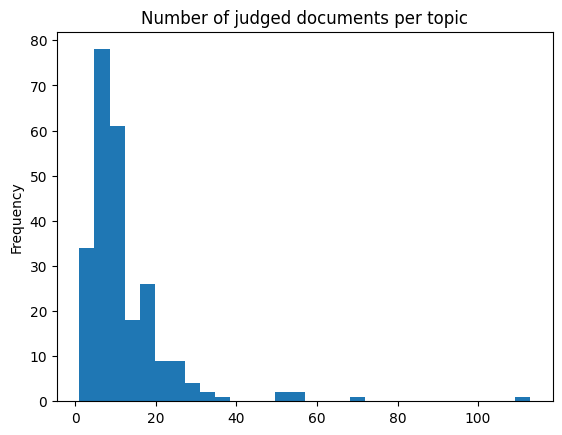

In [16]:
qrels.groupby("query_id").size().plot.hist(bins=30, title="Number of judged documents per topic")


In [29]:
qrels.groupby("query_id").size().sort_values().head(10)

query_id
312    1
666    1
691    1
677    1
607    2
317    2
356    2
345    2
694    2
690    2
dtype: int64

<Axes: title={'center': 'Distribution of judged documents per topic'}>

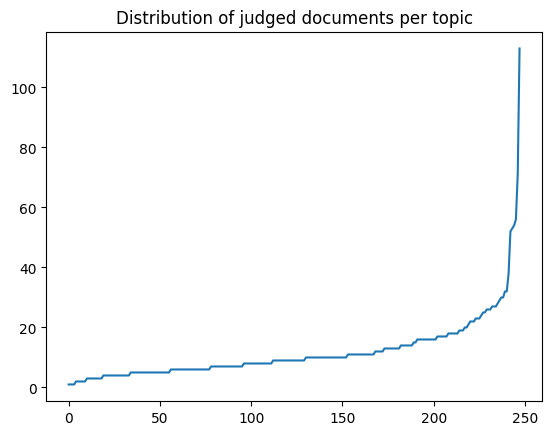

In [33]:
qrels.groupby("query_id").size().sort_values().reset_index()[0].plot.line(title="Distribution of judged documents per topic")

### Do LLM judges benefit from additional information in the topic?
The original TREC topics are judged by an LLM but one or two topic components are masked. For example, the prompt `-DNA-zero-shot-masked-title` only contains the **description** and **narrative** of the TREC topic. 

- Generally the differences are low
- Masking the title outperforms the full topic
- More context seems to be better

In [14]:
# Load generated qrels from path
BASE_DIR = DATA_DIR_INTERIM / "qrels-robust-topics-masked"
predictions, names, metadata = load_qrels_from_path(BASE_DIR)

# binarize qrels
predictions = [binarize_qrels(qrels) for qrels in predictions]

In [15]:
# Evaluate qrels
res = QrelsEvaluator.experiment(
    predictions=predictions,
    references=binarize_qrels(ir_datasets.load(
        "disks45/nocr/trec-robust-2004").qrels_iter()),
    measures=[CohenKappa(), MeanAverageError(), AreaUnderReceiver()],
    bootstrap=20,
    names=names)

[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 19/2932 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 15/2936 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 39/2912 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 21/2930 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 36/2915 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 17/2934 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 18/2933 qrels in references but not in predictions.


In [16]:
df = pd.DataFrame(res)
df["score"] = df.apply(format_score, axis=1)
df = df.pivot(index="name", columns="measure", values="score").reset_index()
df = df.merge(metadata, left_on="name", right_on="date")

partial_annotation_prompts = [
    "-DNA-zero-shot", "-DNA-zero-shot-masked-title", "-DNA-zero-shot-masked-description", "-DNA-zero-shot-masked-narrative",
    "-DNA-zero-shot-masked-title-description", "-DNA-zero-shot-masked-title-narrative", "-DNA-zero-shot-masked-description-narrative"]
df["prompt"] = pd.Categorical(df["prompt"], partial_annotation_prompts)
df.sort_values(by=["model", "prompt"])[
    ["model", "prompt", "CohenKappa", "MeanAverageError", "AreaUnderReceiver"]]

,model,prompt,CohenKappa,MeanAverageError,AreaUnderReceiver
0,gpt-4.1,-DNA-zero-shot,0.64 ± 0.03,0.17 ± 0.01,0.81 ± 0.01
1,qwen3-30B-no-think,-DNA-zero-shot,0.76 ± 0.02,0.10 ± 0.01,0.90 ± 0.01
7,qwen3-30B-no-think,-DNA-zero-shot-masked-title,0.79 ± 0.02,0.09 ± 0.01,0.91 ± 0.01
3,qwen3-30B-no-think,-DNA-zero-shot-masked-description,0.73 ± 0.02,0.12 ± 0.01,0.88 ± 0.01
4,qwen3-30B-no-think,-DNA-zero-shot-masked-narrative,0.73 ± 0.03,0.11 ± 0.01,0.89 ± 0.01
5,qwen3-30B-no-think,-DNA-zero-shot-masked-title-description,0.66 ± 0.03,0.15 ± 0.01,0.85 ± 0.01
6,qwen3-30B-no-think,-DNA-zero-shot-masked-title-narrative,0.72 ± 0.02,0.12 ± 0.01,0.88 ± 0.01
2,qwen3-30B-no-think,-DNA-zero-shot-masked-description-narrative,0.68 ± 0.02,0.13 ± 0.01,0.86 ± 0.01
